# Análisis Exploratorio de Datos (EDA)
## Internet fijo y móvil en el departamento de La Paz

### 1. Introducción
Este EDA se reconstruye desde cero con los **microdatos del Censo de Población y
Vivienda 2024** contenidos en `Base de datos CSV`. La única fuente de observaciones
estadísticas es `Vivienda_CPV-2024.csv`. El diccionario XLSX aporta metadatos y
catálogos; el cuestionario PDF documenta las preguntas y los saltos.
El Excel resumido anterior no se consulta ni se reutilizan sus conclusiones.

El objetivo es describir el acceso declarado a **Internet fijo y móvil en el
departamento de La Paz**, revisar calidad, comparar áreas y territorios y formular
una hipótesis exploratoria. La unidad observada es el **registro de vivienda**:
la pregunta 19 se refiere al equipamiento del hogar, pero no contamos personas
conectadas, contratos, velocidad, uso individual ni cobertura técnica de redes.

**Universo y denominadores.** Las preguntas TIC corresponden a viviendas particulares
con personas presentes (tipos 1–6 y ocupación 0/1, según diccionario y cuestionario).
La tasa principal será `Sí / universo aplicable × 100`, conservando «Sin especificar»
en ese denominador. Se muestran además respuestas determinadas (1/2) y tasas entre
ellas. Los vacíos por salto quedan fuera del universo; nunca se interpretan como «No».
Las comparaciones fijo/móvil usan el mismo denominador. Todos los resultados se
calculan al ejecutar las celdas, sin muestreo ni cruces con microdatos de personas.

El cuestionario se revisó visualmente: página PDF 2 (impresa 1), capítulos B/C,
tipos de vivienda y saltos por ocupación; página PDF 3 (impresa 2), pregunta 19,
Internet fijo en la vivienda e Internet móvil (megas o datos).

### 2. Importación de librerías

In [1]:
from pathlib import Path
import csv
import hashlib
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 25)
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
def entero(n): return f"{int(n):,}".replace(",", ".")
def decimal(n): return f"{float(n):.2f}".replace(".", ",")
def texto(s): display(Markdown(s))

### 3. Localización de archivos
Se admite ejecutar desde la raíz o desde `notebooks/`. Las rutas se construyen a
partir del directorio de trabajo y sus padres; no contienen ubicaciones personales.
Se lista **todo** el contenido antes de cargar los datos. Los archivos
`Zone.Identifier` son metadatos de descarga, no observaciones censales.

In [2]:
RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "Base de datos CSV").is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError("Coloque Base de datos CSV en la raíz y ejecute desde el proyecto.")
DATOS = RAIZ / "Base de datos CSV"
SALIDA = RAIZ / "outputs"
TABLAS = SALIDA / "tablas"
GRAFICOS = SALIDA / "graficos"
for carpeta in [TABLAS, GRAFICOS, SALIDA / "datos"]:
    carpeta.mkdir(parents=True, exist_ok=True)
inventario = pd.DataFrame([
    {"archivo": str(p.relative_to(RAIZ)), "bytes": p.stat().st_size if p.is_file() else 0,
     "clase": ("Metadato de descarga" if "Zone.Identifier" in p.name else
               {".csv": "Microdatos CSV", ".xlsx": "Diccionario", ".pdf": "Cuestionario"}.get(p.suffix.lower(), "Otro"))}
    for p in sorted(DATOS.rglob("*"))
])
display(inventario)
print("Tamaño total:", decimal(inventario.bytes.sum() / 1e9), "GB decimales")

def huella(ruta):
    h = hashlib.sha256()
    with ruta.open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(8 * 1024 * 1024), b""):
            h.update(bloque)
    return h.hexdigest()

CSV_VIVIENDA = DATOS / "Vivienda_CPV-2024.csv"
DICCIONARIO = DATOS / "Diccionario de variables CPV 2024.xlsx"
CUESTIONARIO = DATOS / "Cuestionario censal 2024.pdf"
originales = {p.name: {"bytes": p.stat().st_size, "sha256": huella(p)}
              for p in [CSV_VIVIENDA, DICCIONARIO, CUESTIONARIO]}

,archivo,bytes,clase
0,Base de datos CSV/Cuestionario censal 2024.pdf,21074992,Cuestionario
1,Base de datos CSV/Cuestionario censal 2024.pdf:Zone.Identifier,124,Metadato de descarga
2,Base de datos CSV/Diccionario de variables CPV 2024.xlsx,204479,Diccionario
3,Base de datos CSV/Diccionario de variables CPV 2024.xlsx:Zone.Identifier,124,Metadato de descarga
4,Base de datos CSV/Emigracion_CPV-2024.csv,23806805,Microdatos CSV
5,Base de datos CSV/Emigracion_CPV-2024.csv:Zone.Identifier,124,Metadato de descarga
6,Base de datos CSV/Mortalidad_CPV-2024.csv,19297562,Microdatos CSV
7,Base de datos CSV/Mortalidad_CPV-2024.csv:Zone.Identifier,124,Metadato de descarga
8,Base de datos CSV/Persona_CPV-2024.csv,3087564948,Microdatos CSV
9,Base de datos CSV/Persona_CPV-2024.csv:Zone.Identifier,124,Metadato de descarga


Tamaño total: 3,64 GB decimales


### 4. Carga eficiente del CSV
Primero se detecta el separador de **cada CSV** y se inspeccionan sus encabezados.
UTF-8 se prueba con decodificación estricta; un prefijo ASCII también sería compatible
con otras codificaciones y no basta para identificarlas de manera única. La lectura
completa de Vivienda comprobará que UTF-8 es compatible con todo el archivo.
Se seleccionan 16 de las columnas reales y se procesan bloques de 200.000 filas;
solo se acumulan las filas de La Paz. No se carga `Persona_CPV-2024.csv` completo.

Se leen códigos como texto para conservar ceros iniciales y distinguir campos vacíos
de los códigos 9. Tras filtrar, las columnas repetitivas se compactan como categorías
sin cambiar sus valores; el identificador permanece como texto.
`keep_default_na=False` evita convertir automáticamente tokens del
CSV en nulos. El formato CSV no contiene un tipo nulo nativo: se auditan vacíos,
marcadores literales y nulos de pandas por separado.

In [3]:
def inspeccionar_csv(ruta):
    with ruta.open("r", encoding="utf-8-sig", errors="strict", newline="") as archivo:
        muestra = archivo.read(65536)
    dialecto = csv.Sniffer().sniff(muestra, delimiters=";,\t|")
    cabecera = next(csv.reader(muestra.splitlines(), dialecto))
    return {"archivo": ruta.name, "separador": dialecto.delimiter,
            "codificacion_compatible": "utf-8-sig", "columnas": len(cabecera),
            "cabecera": cabecera}

inspecciones = [inspeccionar_csv(p) for p in sorted(DATOS.glob("*.csv"))]
display(pd.DataFrame(inspecciones).drop(columns="cabecera"))
for item in inspecciones:
    print(item["archivo"], ":", ", ".join(item["cabecera"]))
formato = next(x for x in inspecciones if x["archivo"] == CSV_VIVIENDA.name)
VARIABLES = ["idep", "iprov", "imun", "i00", "urbrur", "v01_tipoviv", "v02_condocup",
             "v09_energia", "v13_habitac", "v14_dormit", "v19c_compu", "v19d_celular",
             "v19e_inetfijo", "v19f_inetmovil", "v19e_f", "tot_pers"]
assert set(VARIABLES).issubset(formato["cabecera"])
print("La base Vivienda contiene todas las variables requeridas. No se necesita un join.")

,archivo,separador,codificacion_compatible,columnas
0,Emigracion_CPV-2024.csv,;,utf-8-sig,8
1,Mortalidad_CPV-2024.csv,;,utf-8-sig,10
2,Persona_CPV-2024.csv,;,utf-8-sig,118
3,Vivienda_CPV-2024.csv,;,utf-8-sig,48


Emigracion_CPV-2024.csv : idep, iprov, imun, i00, e203_sexo, e204_ansal, e205_edad, pais_destino_cod
Mortalidad_CPV-2024.csv : idep, iprov, imun, i00, m212a_mes, m212b_an, m213_edad, m214_cov, m215_sexo, m216_parto
Persona_CPV-2024.csv : idep, iprov, imun, i00, p24_parentes, p25_sexo, p26_edad, p28_cn, p29_ci, p30a_public, p30b_caja, p30c_privad, p30d_atedom, p30e_tradic, p30f_autome, p30g_casera, p31_afiliado, p32_pueblo_per, p32_pueblo_cod, p331_idiohab1_cod, p332_idiohab2_cod, p333_idiohab3_cod, p334_idiohab_no, p341_idiomat_cod, p342_idiomat_no, p35_lugnac, p35j_deptocod, p35h1_provcod, p35h_muncod, p354_anllega, p353_paisnac_cod, p36_lugres, p361_anres, p36j_deptocod, p36h1_provcod, p36h_muncod, p363_paisres_cod, p37_lugres5, p37j_deptocod, p37h1_provcod, p37h_muncod, p373_paisres5_cod, p38_asiste, p39_tipoest, p40_lee, p41a_nivel, p41b_curso, p42a_ver, p42b_oir, p42c_camina, p42d_comuni, p43_pago, p44_nego, p45_agro, p46_dest, p47_otro, p48_nocu, p49_ocu_1d, ocu_1d_19, p50_semp, 

### 5. Diccionario de variables
Se leen todas las hojas del diccionario original y se extraen sus bloques
`Etiqueta`, `Nombre`, `Tipo`, `Rango` y categorías. Los códigos válidos categóricos
son los **enumerados**, no todos los enteros intermedios del rango 1–9.

**Limitación documental de geografía e identificador:** el diccionario no define
directamente `idep`, `iprov`, `imun` ni `i00`. La hoja PERSONA sí incluye los catálogos
`dep_res_cod`, `prov_res_cod` y `mun_res_cod`. Se emplean únicamente como metadatos:
se contrasta la concatenación de los códigos de Vivienda con esos catálogos antes de
asignar nombres. Esto es una correspondencia comprobada de códigos, no un cruce con
registros de personas ni una definición documental de las cuatro columnas ausentes.
`i00` se trata como **identificador candidato**, cuya unicidad se comprueba en La Paz.

In [4]:
hojas = pd.read_excel(DICCIONARIO, sheet_name=None, header=None, dtype=object, engine="openpyxl")
dic = {}
for nombre_hoja, hoja in hojas.items():
    actual, descripcion = None, None
    for fila_excel, fila in enumerate(hoja.itertuples(index=False, name=None), start=1):
        clave, valor = fila[1], fila[2]
        if clave == "Etiqueta":
            descripcion, actual = valor, None
        elif clave == "Nombre":
            actual = str(valor).lower()
            dic[actual] = {"descripcion": descripcion, "categorias": {},
                           "hoja": nombre_hoja, "fila_nombre": fila_excel}
        elif actual and clave == "Tipo":
            dic[actual]["tipo"] = valor
            dic[actual]["rango"] = str(fila[4])
        elif actual and pd.notna(clave) and re.fullmatch(r"\d+(?:\.0)?", str(clave).strip()):
            dic[actual]["categorias"][str(int(float(clave)))] = str(valor)

cat_dep = dic["dep_res_cod"]["categorias"]
cat_prov = dic["prov_res_cod"]["categorias"]
cat_mun = dic["mun_res_cod"]["categorias"]
codigos_lapaz = [k for k, v in cat_dep.items() if v == "La Paz"]
assert len(codigos_lapaz) == 1
CODIGO_LAPAZ = codigos_lapaz[0].zfill(2)

notas_geo = {
    "idep": "Código departamental: correspondencia con dep_res_cod; no definido directamente",
    "iprov": "Componente provincial: idep sin cero + iprov se contrasta con prov_res_cod",
    "imun": "Componente municipal: código provincial + imun se contrasta con mun_res_cod",
    "i00": "Identificador candidato de registro; sin definición directa en el diccionario",
}
tabla_diccionario = pd.DataFrame([
    {"variable": v, "descripcion": dic[v]["descripcion"] if v in dic else notas_geo[v],
     "codigos_o_rango": "; ".join(f"{k}: {lab}" for k, lab in dic[v]["categorias"].items())
         if v in dic and dic[v]["categorias"] else (dic[v].get("rango", "") if v in dic else "Ver nota documental"),
     "fuente": f"{dic[v]['hoja']}, fila {dic[v]['fila_nombre']}" if v in dic else "Correspondencia auditada / limitación"}
    for v in VARIABLES
])
display(tabla_diccionario)
display(pd.DataFrame([{"catalogo": k, "descripcion": dic[k]["descripcion"],
                       "hoja": dic[k]["hoja"], "fila": dic[k]["fila_nombre"]}
                      for k in ["dep_res_cod", "prov_res_cod", "mun_res_cod"]]))
print("La Paz: código", codigos_lapaz[0], "en el diccionario; representación CSV:", CODIGO_LAPAZ)

,variable,descripcion,codigos_o_rango,fuente
0,idep,Código departamental: correspondencia con dep_res_cod; no definido directamente,Ver nota documental,Correspondencia auditada / limitación
1,iprov,Componente provincial: idep sin cero + iprov se contrasta con prov_res_cod,Ver nota documental,Correspondencia auditada / limitación
2,imun,Componente municipal: código provincial + imun se contrasta con mun_res_cod,Ver nota documental,Correspondencia auditada / limitación
3,i00,Identificador candidato de registro; sin definición directa en el diccionario,Ver nota documental,Correspondencia auditada / limitación
4,urbrur,Área Urbana - Rural,1: Urbana; 2: Rural,"VIVIENDA, fila 6"
5,v01_tipoviv,1. La vivienda es: (Tipo de vivienda),"1: Casa; 2: Choza, pahuichi; 3: Departamento; 4: Cuarto(s) o habitación(es) suelta(s); 5: Vivienda improvi...","VIVIENDA, fila 13"
6,v02_condocup,2. La vivienda esta: (Condición de ocupación de la vivienda),0: Ocupada con personas presentes sin Jefe; 1: Ocupada con personas presentes; 2: Ocupada con personas tem...,"VIVIENDA, fila 34"
7,v09_energia,9. De donde proviene la energía eléctrica que usan en la vivienda,1: Servicio público de energía eléctrica; 2: Motor propio (Generador); 3: Panel solar; 4: Otro; 5: No tiene,"VIVIENDA, fila 110"
8,v13_habitac,"13. Cuántos cuartos o habitaciones ocupan, sin contar baño y cocina",1: Uno; 2: Dos; 3: Tres; 4: Cuatro; 5: Cinco; 6: Seis; 7: Siete; 8: Ocho o más,"VIVIENDA, fila 152"
9,v14_dormit,"14. De estos cuartos o habitaciones, Cuántos se utilizan solo para dormir",0: Cero; 1: Uno; 2: Dos; 3: Tres; 4: Cuatro; 5: Cinco; 6: Seis; 7: Siete; 8: Ocho o más,"VIVIENDA, fila 165"


,catalogo,descripcion,hoja,fila
0,dep_res_cod,Departamento de residencia habitual (residentes en el país y que respondieron a la pregunta),PERSONA,3644
1,prov_res_cod,Provincia de residencia habitual (residentes en el país y que respondieron a la pregunta),PERSONA,3659
2,mun_res_cod,Municipio de residencia habitual (residentes en el país y que respondieron a la pregunta),PERSONA,3787


La Paz: código 2 en el diccionario; representación CSV: 02


### 6. Filtro La Paz

In [5]:
partes = []
registros_nacionales = 0
conteo_departamentos = pd.Series(dtype="int64")
for bloque in pd.read_csv(CSV_VIVIENDA, sep=formato["separador"],
                          encoding=formato["codificacion_compatible"], encoding_errors="strict",
                          usecols=VARIABLES, dtype="string", keep_default_na=False,
                          low_memory=False, chunksize=200_000):
    registros_nacionales += len(bloque)
    conteo_departamentos = conteo_departamentos.add(bloque.idep.value_counts(), fill_value=0)
    partes.append(bloque.loc[bloque.idep.eq(CODIGO_LAPAZ), VARIABLES].copy())
df_lapaz = pd.concat(partes, ignore_index=True)
del partes, bloque
for v in VARIABLES:
    if v != "i00":
        df_lapaz[v] = df_lapaz[v].astype("category")
assert df_lapaz.idep.eq(CODIGO_LAPAZ).all() and len(df_lapaz) > 0
display(conteo_departamentos.rename("registros").astype("int64").to_frame())
assert set(conteo_departamentos.index.str.lstrip("0")).issubset(cat_dep)
print("Registros antes del filtro:", entero(registros_nacionales))
print("Registros después del filtro:", entero(len(df_lapaz)))

# Copia local explícita de las 16 columnas originales, sin etiquetas ni imputaciones.
COPIA_LAPAZ = SALIDA / "datos" / "vivienda_lapaz_seleccion.csv.gz"
df_lapaz.to_csv(COPIA_LAPAZ, sep=";", index=False, encoding="utf-8",
                compression={"method": "gzip", "compresslevel": 1, "mtime": 0})
print("Copia filtrada local:", COPIA_LAPAZ.relative_to(RAIZ))

,registros
idep,
01,246886
02,1334496
03,843762
04,271078
05,383505
06,199991
07,1021836
08,146098
09,42836


Registros antes del filtro: 4.490.488
Registros después del filtro: 1.334.496


Copia filtrada local: outputs/datos/vivienda_lapaz_seleccion.csv.gz


### 7. MISIÓN 1: estructura
Los valores de los códigos se conservan como texto dentro de columnas categóricas,
mientras que `i00` mantiene el tipo string. Esta compactación reduce la memoria sin
recodificar respuestas ni perder ceros iniciales.
La cantidad de columnas del archivo original se distingue de las seleccionadas y
de las etiquetas que se crearán después. `tot_pers` representa el total de personas
del registro; los registros colectivos pueden tener tamaños muy grandes y no deben
interpretarse como hogares particulares atípicos.

In [6]:
resumen_estructura = pd.DataFrame({"medida": ["Registros nacionales", "Registros de La Paz",
    "Variables del CSV original", "Variables originales seleccionadas"],
    "valor": [registros_nacionales, len(df_lapaz), len(formato["cabecera"]), len(VARIABLES)]})
display(resumen_estructura)
display(df_lapaz.dtypes.rename("tipo_de_lectura").to_frame())
print("Columnas:", list(df_lapaz.columns))
display(df_lapaz.head())
df_lapaz.info(memory_usage="deep")
texto(f"Se analizan **{entero(len(df_lapaz))} registros de La Paz** y **{len(VARIABLES)} variables** "
      f"de las {len(formato['cabecera'])} originales. Se conserva la totalidad del departamento.")

,medida,valor
0,Registros nacionales,4490488
1,Registros de La Paz,1334496
2,Variables del CSV original,48
3,Variables originales seleccionadas,16


,tipo_de_lectura
idep,category
iprov,category
imun,category
i00,string
urbrur,category
v01_tipoviv,category
v02_condocup,category
v09_energia,category
v13_habitac,category
v14_dormit,category


Columnas: ['idep', 'iprov', 'imun', 'i00', 'urbrur', 'v01_tipoviv', 'v02_condocup', 'v09_energia', 'v13_habitac', 'v14_dormit', 'v19c_compu', 'v19d_celular', 'v19e_inetfijo', 'v19f_inetmovil', 'v19e_f', 'tot_pers']


,idep,iprov,imun,i00,urbrur,v01_tipoviv,v02_condocup,v09_energia,v13_habitac,v14_dormit,v19c_compu,v19d_celular,v19e_inetfijo,v19f_inetmovil,v19e_f,tot_pers
0,02,02,01,01234493,2,1,2,,,,,,,,,0
1,02,01,05,00474168,1,16,,,,,,,,,,1
2,02,01,01,00354719,1,1,2,,,,,,,,,0
3,02,01,01,00264481,1,7,,,,,,,,,,4
4,02,01,05,00646698,1,2,5,,,,,,,,,0


<class 'pandas.DataFrame'>
RangeIndex: 1334496 entries, 0 to 1334495
Data columns (total 16 columns):
 #   Column          Non-Null Count    Dtype   
---  ------          --------------    -----   
 0   idep            1334496 non-null  category
 1   iprov           1334496 non-null  category
 2   imun            1334496 non-null  category
 3   i00             1334496 non-null  string  
 4   urbrur          1334496 non-null  category
 5   v01_tipoviv     1334496 non-null  category
 6   v02_condocup    1334496 non-null  category
 7   v09_energia     1334496 non-null  category
 8   v13_habitac     1334496 non-null  category
 9   v14_dormit      1334496 non-null  category
 10  v19c_compu      1334496 non-null  category
 11  v19d_celular    1334496 non-null  category
 12  v19e_inetfijo   1334496 non-null  category
 13  v19f_inetmovil  1334496 non-null  category
 14  v19e_f          1334496 non-null  category
 15  tot_pers        1334496 non-null  category
dtypes: category(15), string(1)
me

Se analizan **1.334.496 registros de La Paz** y **16 variables** de las 48 originales. Se conserva la totalidad del departamento.

### 8. MISIÓN 2: valores faltantes
Se distinguen nulos de pandas, vacíos físicos, marcadores textuales de ausencia,
categorías «Sin especificar» y categorías «No aplica» explícitas en el diccionario.
No se recodifica globalmente 9: por ejemplo, en tipo de vivienda 9 significa cuartel.
La categoría «No aplica» no está enumerada en las variables seleccionadas; los
vacíos por saltos se identifican aparte utilizando tipo y ocupación.

In [7]:
def codigos_con_texto(variable, patron):
    return [k for k, v in dic.get(variable, {}).get("categorias", {}).items()
            if patron in v.casefold()]

filas_calidad = []
for v in VARIABLES:
    s = df_lapaz[v]
    mediciones = {"nulos_pandas": int(s.isna().sum()),
                  "vacios_csv": int(s.eq("").sum()),
                  "solo_espacios": int((s.ne("") & s.str.strip().eq("")).sum()),
                  "marcadores_NaN_NULL_NA": int(s.str.upper().isin(["NAN", "NULL", "NA", "N/A"]).sum()),
                  "sin_especificar": int(s.isin(codigos_con_texto(v, "sin especificar")).sum()),
                  "no_aplica_codificado": int(s.isin(codigos_con_texto(v, "no aplica")).sum())}
    filas_calidad.append({"variable": v, **mediciones,
                         **{f"{k}_pct": n / len(df_lapaz) * 100 for k, n in mediciones.items()}})
faltantes = pd.DataFrame(filas_calidad).set_index("variable")
display(faltantes)

es_particular = df_lapaz.v01_tipoviv.isin(["1", "2", "3", "4", "5", "6"])
es_presente = df_lapaz.v02_condocup.isin(["0", "1"])
aplicable = es_particular & es_presente
INTERNET = {"Fijo": "v19e_inetfijo", "Móvil": "v19f_inetmovil", "Algún internet": "v19e_f"}
universo_n = int(aplicable.sum())
auditoria_universo = pd.DataFrame([
    {"variable": v, "vacios_dentro_universo": int((aplicable & df_lapaz[v].eq("")).sum()),
     "vacios_fuera_universo": int((~aplicable & df_lapaz[v].eq("")).sum()),
     "respuesta_fuera_universo": int((~aplicable & df_lapaz[v].ne("")).sum()),
     "sin_especificar_dentro": int((aplicable & df_lapaz[v].eq("9")).sum())}
    for v in INTERNET.values()
])
display(auditoria_universo)
display(pd.crosstab(df_lapaz.v02_condocup.astype("string").replace("", "Vacío CSV"),
                    df_lapaz.v19e_f.astype("string").replace("", "Vacío CSV"), margins=True))
texto(f"El universo TIC contiene **{entero(universo_n)} viviendas**. "
      f"Los **{entero((~aplicable).sum())} registros fuera del universo** no entran en las tasas. "
      "El código 0 de ocupación corresponde a personas presentes sin jefe, según el diccionario; se incluye.")

,nulos_pandas,vacios_csv,solo_espacios,marcadores_NaN_NULL_NA,sin_especificar,no_aplica_codificado,nulos_pandas_pct,vacios_csv_pct,solo_espacios_pct,marcadores_NaN_NULL_NA_pct,sin_especificar_pct,no_aplica_codificado_pct
variable,,,,,,,,,,,,
idep,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
iprov,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
imun,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
i00,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
urbrur,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
v01_tipoviv,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
v02_condocup,0,6737,0,0,0,0,0.00,0.50,0.00,0.00,0.00,0.00
v09_energia,0,264658,0,0,0,0,0.00,19.83,0.00,0.00,0.00,0.00
v13_habitac,0,264658,0,0,0,0,0.00,19.83,0.00,0.00,0.00,0.00


,variable,vacios_dentro_universo,vacios_fuera_universo,respuesta_fuera_universo,sin_especificar_dentro
0,v19e_inetfijo,0,264658,0,30542
1,v19f_inetmovil,0,264658,0,30577
2,v19e_f,0,264658,0,30497


v19e_f,1,2,9,Vacío CSV,All
v02_condocup,,,,,
0,692,769,100,0,1561
1,747709,290171,30397,0,1068277
2,0,0,0,156896,156896
3,0,0,0,24846,24846
4,0,0,0,22032,22032
5,0,0,0,54147,54147
Vacío CSV,0,0,0,6737,6737
All,748401,290940,30497,264658,1334496


El universo TIC contiene **1.069.838 viviendas**. Los **264.658 registros fuera del universo** no entran en las tasas. El código 0 de ocupación corresponde a personas presentes sin jefe, según el diccionario; se incluye.

### 9. Duplicados
Se verifica `i00` y la clave candidata compuesta `idep, iprov, imun, i00` en todo
La Paz. Se informa también repetición exacta de las 16 columnas seleccionadas.
Si el identificador es único, ninguna fila completa del CSV puede estar repetida
dentro de La Paz. La documentación no garantiza formalmente su semántica ni se
audita aquí su unicidad nacional. Perfiles TIC iguales de viviendas diferentes no
son duplicados. No se elimina ningún registro.

In [8]:
duplicados = {
    "i00_vacio": int(df_lapaz.i00.eq("").sum()),
    "i00_repeticiones_adicionales": int(df_lapaz.i00.duplicated().sum()),
    "i00_filas_involucradas": int(df_lapaz.i00.duplicated(keep=False).sum()),
    "clave_compuesta_repeticiones": int(df_lapaz.duplicated(["idep", "iprov", "imun", "i00"]).sum()),
    "filas_iguales_16_columnas": int(df_lapaz.duplicated().sum()),
}
display(pd.Series(duplicados, name="cantidad").to_frame())

,cantidad
i00_vacio,0
i00_repeticiones_adicionales,0
i00_filas_involucradas,0
clave_compuesta_repeticiones,0
filas_iguales_16_columnas,0


### 10. Inconsistencias
Se contrastan categorías enumeradas y el rango numérico de `tot_pers` (0–9999).
Los códigos provinciales/municipales se componen preservando sus dos dígitos:
`02 + 01 + 01 → 20101`. Se valida su existencia y coherencia jerárquica con los
catálogos del propio diccionario. Los nombres solo se asignan donde hay coincidencia.

La combinada oficial se compara con una regla trivalente conservadora: «Sí» si
alguna modalidad es 1; «No» solo si ambas son 2; «Sin especificar» si falta certeza
y los códigos pertenecen al catálogo. Una discrepancia con esa regla no prueba un
error del INE: el diccionario no explica el algoritmo de construcción oficial.

In [9]:
fuera_catalogo = []
for v in VARIABLES:
    if v not in dic:
        continue
    s = df_lapaz[v]
    if dic[v]["categorias"]:
        malo = s.ne("") & ~s.isin(dic[v]["categorias"])
    else:
        limites = [int(x) for x in re.findall(r"\d+", dic[v]["rango"])]
        n = pd.to_numeric(s, errors="coerce")
        malo = s.ne("") & (~n.between(*limites) | n.isna() | n.mod(1).ne(0))
    fuera_catalogo.append({"variable": v, "fuera_catalogo": int(malo.sum()),
                           "valores": s[malo].value_counts().to_dict()})
fuera_catalogo = pd.DataFrame(fuera_catalogo)
display(fuera_catalogo)

prov_cod = df_lapaz.idep.astype("string").str.lstrip("0") + df_lapaz.iprov.astype("string")
mun_cod = prov_cod + df_lapaz.imun.astype("string")
auditoria_geo = pd.DataFrame({"medida": ["Códigos geográficos vacíos (celdas)",
    "Formato distinto de dos dígitos (celdas)", "Provincia sin correspondencia", "Municipio sin correspondencia"],
    "cantidad": [int(df_lapaz[["idep", "iprov", "imun"]].eq("").sum().sum()),
                 sum(int((~df_lapaz[c].str.fullmatch(r"\d{2}")).sum()) for c in ["idep", "iprov", "imun"]),
                 int((~prov_cod.isin(cat_prov)).sum()), int((~mun_cod.isin(cat_mun)).sum())]})
display(auditoria_geo)
geografia = pd.DataFrame({"provincia_codigo": prov_cod, "municipio_codigo": mun_cod}).drop_duplicates()
geografia["provincia"] = geografia.provincia_codigo.map(cat_prov)
geografia["municipio"] = geografia.municipio_codigo.map(cat_mun)
display(geografia.sort_values("municipio_codigo").head(10))

f, m, oficial = (df_lapaz[v] for v in INTERNET.values())
regla = pd.Series("Fuera del universo", index=df_lapaz.index, dtype="string")
regla.loc[aplicable] = "9"
regla.loc[aplicable & (f.eq("1") | m.eq("1"))] = "1"
regla.loc[aplicable & f.eq("2") & m.eq("2")] = "2"
regla.loc[aplicable & (~f.isin(["1", "2", "9"]) | ~m.isin(["1", "2", "9"]))] = "Sin dato / código inválido"
discrepancia = aplicable & oficial.ne(regla)
contradiccion_cierta = aplicable & ((regla.eq("1") & oficial.eq("2")) | (regla.eq("2") & oficial.eq("1")))
inconsistencias = {
    "codigos_fuera_catalogo": int(fuera_catalogo.fuera_catalogo.sum()),
    "dormitorios_mayores_que_habitaciones": int((pd.to_numeric(df_lapaz.v14_dormit, errors="coerce") >
                                                pd.to_numeric(df_lapaz.v13_habitac, errors="coerce")).sum()),
    "internet_informado_fuera_universo": int((~aplicable & oficial.ne("")).sum()),
    "particulares_presentes_sin_personas": int((aplicable & df_lapaz.tot_pers.eq("0")).sum()),
    "combinada_discrepa_regla_conservadora": int(discrepancia.sum()),
    "combinada_contradiccion_si_no_determinada": int(contradiccion_cierta.sum()),
}
display(pd.Series(inconsistencias, name="cantidad").to_frame())
display(df_lapaz.loc[discrepancia, list(INTERNET.values())].value_counts().rename("registros").to_frame())
texto(f"Se observan **{entero(discrepancia.sum())} discrepancias** con la regla conservadora, "
      f"de las cuales **{entero(contradiccion_cierta.sum())}** son contradicciones determinadas Sí/No. "
      "Se conservan los códigos oficiales y se presenta sensibilidad en la sección 14. "
      "Tener Internet y declarar no tener electricidad o celular no se considera por sí solo una combinación imposible.")

,variable,fuera_catalogo,valores
0,urbrur,0,"{'1': 0, '2': 0}"
1,v01_tipoviv,0,"{'1': 0, '10': 0, '11': 0, '12': 0, '13': 0, '14': 0, '15': 0, '16': 0, '2': 0, '3': 0, '4': 0, '5': 0, '6..."
2,v02_condocup,0,"{'': 0, '0': 0, '1': 0, '2': 0, '3': 0, '4': 0, '5': 0}"
3,v09_energia,0,"{'': 0, '1': 0, '2': 0, '3': 0, '4': 0, '5': 0}"
4,v13_habitac,0,"{'': 0, '1': 0, '2': 0, '3': 0, '4': 0, '5': 0, '6': 0, '7': 0, '8': 0}"
5,v14_dormit,0,"{'': 0, '0': 0, '1': 0, '2': 0, '3': 0, '4': 0, '5': 0, '6': 0, '7': 0, '8': 0}"
6,v19c_compu,0,"{'': 0, '1': 0, '2': 0, '9': 0}"
7,v19d_celular,0,"{'': 0, '1': 0, '2': 0, '9': 0}"
8,v19e_inetfijo,0,"{'': 0, '1': 0, '2': 0, '9': 0}"
9,v19f_inetmovil,0,"{'': 0, '1': 0, '2': 0, '9': 0}"


,medida,cantidad
0,Códigos geográficos vacíos (celdas),0
1,Formato distinto de dos dígitos (celdas),0
2,Provincia sin correspondencia,0
3,Municipio sin correspondencia,0


,provincia_codigo,municipio_codigo,provincia,municipio
2,201,20101,Murillo,Nuestra Señora de La Paz
151,201,20102,Murillo,Palca
110,201,20103,Murillo,Mecapaca
25,201,20104,Murillo,Achocalla
1,201,20105,Murillo,El Alto
0,202,20201,Omasuyos,Achacachi
45,202,20202,Omasuyos,Villa Ancoraimes
117,202,20203,Omasuyos,Huarina
387,202,20204,Omasuyos,Santiago de Huata
270,202,20205,Omasuyos,Huatajata


,cantidad
codigos_fuera_catalogo,0
dormitorios_mayores_que_habitaciones,0
internet_informado_fuera_universo,0
particulares_presentes_sin_personas,0
combinada_discrepa_regla_conservadora,125
combinada_contradiccion_si_no_determinada,0


registros
v19e_inetfijo v19f_inetmovil v19e_f           
2             9              2              80
9             2              2              45
                                             0
                             1               0
                             9               0
...                                        ...
1                            9               0
              1              2               0
                                             0
                             1               0
                             9               0

[64 rows x 1 columns]

Se observan **125 discrepancias** con la regla conservadora, de las cuales **0** son contradicciones determinadas Sí/No. Se conservan los códigos oficiales y se presenta sensibilidad en la sección 14. Tener Internet y declarar no tener electricidad o celular no se considera por sí solo una combinación imposible.

### 11. Recodificación legible
`df_lapaz` mantiene intactas las 16 columnas originales. `df_analisis` es una copia
del universo aplicable, con códigos categóricos para reducir memoria y nuevas
etiquetas leídas del diccionario. Las variables numéricas conservan su original.
Las tablas separan el universo aplicable, respuestas determinadas y sin especificar.

In [10]:
df_analisis = df_lapaz.loc[aplicable].copy()
for v in VARIABLES:
    if v != "i00":
        df_analisis[v] = df_analisis[v].astype("category")
for variable, etiqueta in [("v19e_inetfijo", "internet_fijo_label"),
                           ("v19f_inetmovil", "internet_movil_label"),
                           ("v19e_f", "internet_combinado_label"), ("urbrur", "area_label")]:
    df_analisis[etiqueta] = df_analisis[variable].astype("string").map(dic[variable]["categorias"]).fillna("Sin dato / fuera de catálogo")
df_analisis["provincia_codigo"] = prov_cod.loc[aplicable]
df_analisis["municipio_codigo"] = mun_cod.loc[aplicable]
df_analisis["provincia"] = df_analisis.provincia_codigo.map(cat_prov).fillna("Sin nombre en catálogo")
df_analisis["municipio"] = df_analisis.municipio_codigo.map(cat_mun).fillna("Sin nombre en catálogo")
df_analisis["total_personas_num"] = pd.to_numeric(df_analisis.tot_pers.astype("string"), errors="raise").astype("Int16")
display(df_analisis[["v19e_inetfijo", "internet_fijo_label", "v19f_inetmovil", "internet_movil_label",
                      "urbrur", "area_label", "municipio_codigo", "municipio"]].head())

def tabla_acceso(variable):
    categorias = dic[variable]["categorias"]
    conteos = df_analisis[variable].value_counts().reindex(categorias, fill_value=0)
    tabla = pd.DataFrame({"codigo": list(categorias), "respuesta": list(categorias.values()),
                          "registros": conteos.to_numpy()})
    tabla["pct_universo_aplicable"] = tabla.registros / universo_n * 100
    determinados = int(df_analisis[variable].isin(["1", "2"]).sum())
    tabla["pct_respuestas_determinadas"] = np.where(tabla.codigo.isin(["1", "2"]),
                                                   tabla.registros / determinados * 100, np.nan)
    assert int(tabla.registros.sum()) == universo_n, "Revisar valores sin categoría dentro del universo"
    return tabla

def guardar_figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(GRAFICOS / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def grafico_acceso(tabla, titulo, nombre):
    fig, ax = plt.subplots(figsize=(8, 4))
    barras = ax.bar(tabla.respuesta, tabla.pct_universo_aplicable,
                    color=["#197c80", "#bb603d", "#8793a4"], label="Sobre universo TIC aplicable")
    ax.bar_label(barras, labels=[f"{decimal(x)} %" for x in tabla.pct_universo_aplicable], padding=3)
    ax.set(title=titulo, xlabel="Respuesta oficial", ylabel="Viviendas del universo aplicable (%)", ylim=(0, 105))
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.legend(loc="upper right", fontsize=9)
    guardar_figura(fig, nombre)

,v19e_inetfijo,internet_fijo_label,v19f_inetmovil,internet_movil_label,urbrur,area_label,municipio_codigo,municipio
222,2,No,1,Sí,2,Rural,20103,Mecapaca
414,2,No,2,No,1,Urbana,20105,El Alto
419,1,Sí,1,Sí,2,Rural,20103,Mecapaca
425,1,Sí,1,Sí,2,Rural,20103,Mecapaca
967,1,Sí,2,No,1,Urbana,20105,El Alto


### 12. Internet fijo en La Paz

,codigo,respuesta,registros,pct_universo_aplicable,pct_respuestas_determinadas
0,1,Sí,362858,33.92,34.91
1,2,No,676438,63.23,65.09
2,9,Sin especificar,30542,2.85,NaN


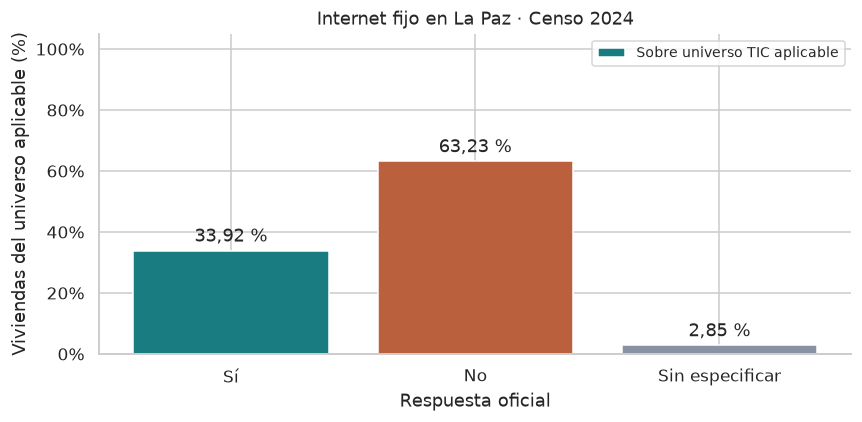

**362.858 viviendas** declaran Internet fijo: **33,92 %** del universo TIC. Entre respuestas determinadas Sí/No, la proporción es **34,91 %**. La segunda tasa excluye Sin especificar y responde a un denominador diferente.

In [11]:
tabla_fijo = tabla_acceso("v19e_inetfijo")
display(tabla_fijo)
grafico_acceso(tabla_fijo, "Internet fijo en La Paz · Censo 2024", "12_internet_fijo")
fila_si = tabla_fijo.set_index("codigo").loc["1"]
texto(f"**{entero(fila_si.registros)} viviendas** declaran Internet fijo: "
      f"**{decimal(fila_si.pct_universo_aplicable)} %** del universo TIC. "
      f"Entre respuestas determinadas Sí/No, la proporción es "
      f"**{decimal(fila_si.pct_respuestas_determinadas)} %**. "
      "La segunda tasa excluye Sin especificar y responde a un denominador diferente.")

### 13. Internet móvil en La Paz

,codigo,respuesta,registros,pct_universo_aplicable,pct_respuestas_determinadas
0,1,Sí,669213,62.55,64.39
1,2,No,370048,34.59,35.61
2,9,Sin especificar,30577,2.86,NaN


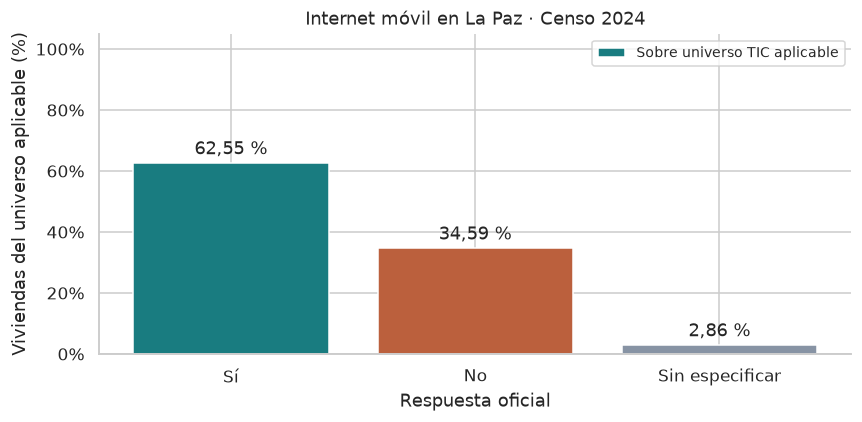

**669.213 viviendas** declaran Internet móvil: **62,55 %** del universo TIC. Entre respuestas determinadas Sí/No, la proporción es **64,39 %**. La segunda tasa excluye Sin especificar y responde a un denominador diferente.

In [12]:
tabla_movil = tabla_acceso("v19f_inetmovil")
display(tabla_movil)
grafico_acceso(tabla_movil, "Internet móvil en La Paz · Censo 2024", "13_internet_movil")
fila_si = tabla_movil.set_index("codigo").loc["1"]
texto(f"**{entero(fila_si.registros)} viviendas** declaran Internet móvil: "
      f"**{decimal(fila_si.pct_universo_aplicable)} %** del universo TIC. "
      f"Entre respuestas determinadas Sí/No, la proporción es "
      f"**{decimal(fila_si.pct_respuestas_determinadas)} %**. "
      "La segunda tasa excluye Sin especificar y responde a un denominador diferente.")

### 14. Internet fijo o móvil
Se utiliza **`v19e_f`**, definida en el diccionario como «Internet fijo en la vivienda
o internet móvil». No se suman los accesos fijo y móvil, porque una vivienda puede
tener ambos. La variable oficial se conserva incluso cuando difiere de la regla
conservadora; esta última solo sirve para auditar y evaluar sensibilidad.

,codigo,respuesta,registros,pct_universo_aplicable,pct_respuestas_determinadas
0,1,Sí,748401,69.95,72.01
1,2,No,290940,27.19,27.99
2,9,Sin especificar,30497,2.85,NaN


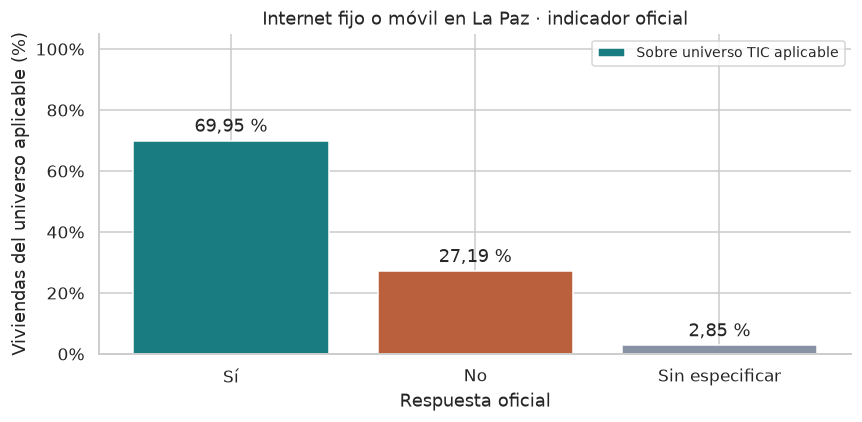

,Oficial,Regla conservadora
Sí,748401,748401
No,290940,290815
Sin especificar,30497,30622


,indicador,si,validos_si_no,pct_universo,pct_determinados
0,Oficial,748401,1039341,69.95,72.01
1,Conservador,748401,1039216,69.95,72.02


**283.670 viviendas** declaran ambas modalidades. Las **125 discrepancias** trasladan casos de No a Sin especificar con la regla conservadora. El número de Sí y su tasa sobre el universo no cambian; sí cambia ligeramente la tasa entre respuestas determinadas.

In [13]:
tabla_combinada = tabla_acceso("v19e_f")
display(tabla_combinada)
grafico_acceso(tabla_combinada, "Internet fijo o móvil en La Paz · indicador oficial", "14_algun_internet")
sensibilidad = pd.DataFrame({
    "Oficial": oficial.loc[aplicable].value_counts().reindex(["1", "2", "9"], fill_value=0),
    "Regla conservadora": regla.loc[aplicable].value_counts().reindex(["1", "2", "9"], fill_value=0)
}).rename(index=dic["v19e_f"]["categorias"])
display(sensibilidad)
sensibilidad_tasas = pd.DataFrame([
    {"indicador": nombre, "si": int(s.eq("1").sum()), "validos_si_no": int(s.isin(["1", "2"]).sum()),
     "pct_universo": s.eq("1").sum() / universo_n * 100,
     "pct_determinados": s.eq("1").sum() / s.isin(["1", "2"]).sum() * 100}
    for nombre, s in [("Oficial", oficial.loc[aplicable]), ("Conservador", regla.loc[aplicable])]
])
display(sensibilidad_tasas)
ambos = int((f.loc[aplicable].eq("1") & m.loc[aplicable].eq("1")).sum())
texto(f"**{entero(ambos)} viviendas** declaran ambas modalidades. "
      f"Las **{entero(discrepancia.sum())} discrepancias** trasladan casos de No a Sin especificar "
      "con la regla conservadora. El número de Sí y su tasa sobre el universo no cambian; "
      "sí cambia ligeramente la tasa entre respuestas determinadas.")

### 15. Comparación general: fijo frente a móvil

,Sí,No,Sin especificar,universo,validos_si_no,% Sí,% No,% Sin especificar,% Sí entre determinados
tipo,,,,,,,,,
Fijo,362858,676438,30542,1069838,1039296,33.92,63.23,2.85,34.91
Móvil,669213,370048,30577,1069838,1039261,62.55,34.59,2.86,64.39
Algún internet,748401,290940,30497,1069838,1039341,69.95,27.19,2.85,72.01


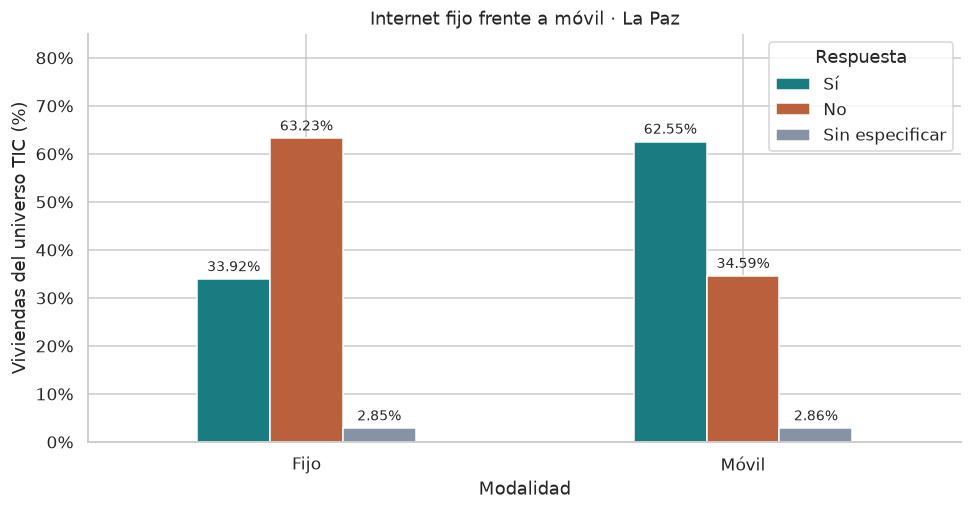

Internet móvil tiene mayor acceso declarado: **306.355 viviendas más** y **28,64 puntos porcentuales** por encima del fijo. La diferencia relativa respecto al fijo es **84,43 %**. Puntos porcentuales y variación relativa son medidas distintas; las modalidades se solapan.

In [14]:
comparacion = pd.DataFrame([
    {"tipo": nombre, "Sí": int(df_analisis[v].eq("1").sum()),
     "No": int(df_analisis[v].eq("2").sum()), "Sin especificar": int(df_analisis[v].eq("9").sum()),
     "universo": universo_n, "validos_si_no": int(df_analisis[v].isin(["1", "2"]).sum())}
    for nombre, v in INTERNET.items()
]).set_index("tipo")
for c in ["Sí", "No", "Sin especificar"]:
    comparacion[f"% {c}"] = comparacion[c] / comparacion.universo * 100
comparacion["% Sí entre determinados"] = comparacion["Sí"] / comparacion.validos_si_no * 100
display(comparacion)
fig, ax = plt.subplots(figsize=(9, 4.8))
comparacion.loc[["Fijo", "Móvil"], ["% Sí", "% No", "% Sin especificar"]].plot.bar(
    ax=ax, color=["#197c80", "#bb603d", "#8793a4"], rot=0)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.2f%%", padding=3, fontsize=9)
ax.set(title="Internet fijo frente a móvil · La Paz", xlabel="Modalidad", ylabel="Viviendas del universo TIC (%)", ylim=(0, 85))
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend(title="Respuesta", labels=["Sí", "No", "Sin especificar"])
guardar_figura(fig, "15_fijo_vs_movil")
dif_absoluta = int(comparacion.loc["Móvil", "Sí"] - comparacion.loc["Fijo", "Sí"])
dif_pp = float(comparacion.loc["Móvil", "% Sí"] - comparacion.loc["Fijo", "% Sí"])
dif_relativa = dif_absoluta / comparacion.loc["Fijo", "Sí"] * 100
texto(f"Internet móvil tiene mayor acceso declarado: **{entero(dif_absoluta)} viviendas más** y "
      f"**{decimal(dif_pp)} puntos porcentuales** por encima del fijo. "
      f"La diferencia relativa respecto al fijo es **{decimal(dif_relativa)} %**. "
      "Puntos porcentuales y variación relativa son medidas distintas; las modalidades se solapan.")

### 16. Área urbana y rural
Todas las tasas principales de una fila usan el mismo universo aplicable del área.
Se añaden los denominadores de respuestas determinadas por modalidad. Las tasas
«Algún internet», «Sin internet» y «Sin especificar combinado» suman 100 %.

,universo,validos_fijo,validos_movil,validos_algun,pct_fijo,pct_movil,pct_algun,pct_sin_internet,pct_sin_especificar
area_label,,,,,,,,,
Urbana,664447,650466,650461,650481,53.07,72.61,84.07,13.83,2.10
Rural,405391,388830,388800,388860,2.52,46.06,46.82,49.10,4.08


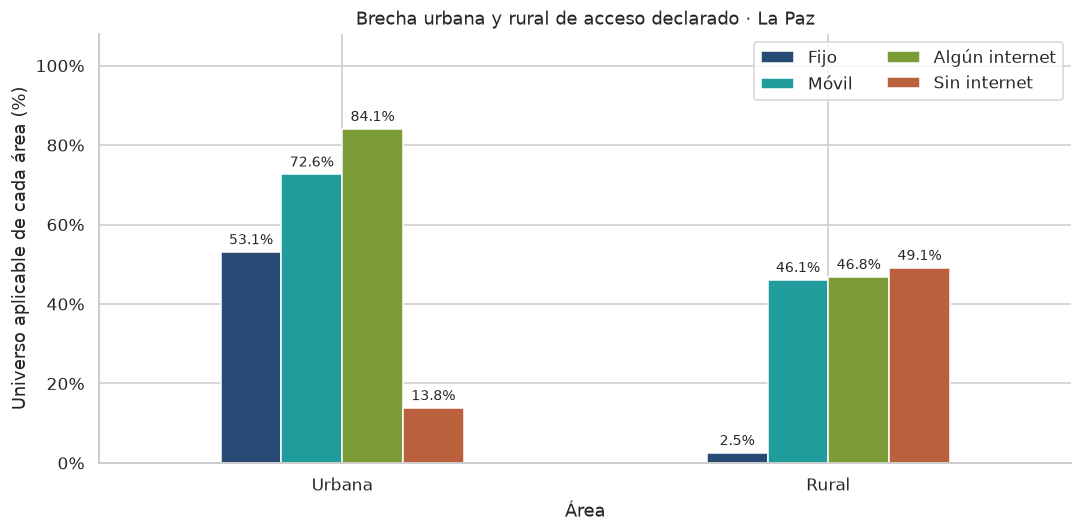

Algún Internet: **84,07 % urbano** frente a **46,82 % rural**, una brecha de **37,25 puntos porcentuales**. Es una asociación descriptiva; el EDA no identifica el efecto causal de vivir en un área.

In [15]:
def resumen_grupos(columnas):
    agrupacion = df_analisis.groupby(columnas, observed=True, dropna=False)
    tabla = agrupacion.size().rename("universo").to_frame()
    for nombre, v in [("fijo", "v19e_inetfijo"), ("movil", "v19f_inetmovil"), ("algun", "v19e_f")]:
        conteos = df_analisis.groupby(columnas + [v], observed=True, dropna=False).size().unstack(v, fill_value=0)
        for codigo, sufijo in [("1", "si"), ("2", "no"), ("9", "sin_especificar")]:
            tabla[f"{nombre}_{sufijo}"] = conteos.get(codigo, pd.Series(0, index=tabla.index)).reindex(tabla.index, fill_value=0)
        tabla[f"validos_{nombre}"] = tabla[f"{nombre}_si"] + tabla[f"{nombre}_no"]
        tabla[f"pct_{nombre}"] = tabla[f"{nombre}_si"] / tabla.universo * 100
        tabla[f"pct_{nombre}_determinados"] = tabla[f"{nombre}_si"] / tabla[f"validos_{nombre}"].replace(0, np.nan) * 100
    tabla["pct_sin_internet"] = tabla.algun_no / tabla.universo * 100
    tabla["pct_sin_especificar"] = tabla.algun_sin_especificar / tabla.universo * 100
    tabla["brecha_movil_fijo_pp"] = tabla.pct_movil - tabla.pct_fijo
    return tabla

areas = resumen_grupos(["area_label"]).reindex(["Urbana", "Rural"])
COLUMNAS_RESUMEN = ["universo", "validos_fijo", "validos_movil", "validos_algun", "pct_fijo", "pct_movil",
                    "pct_algun", "pct_sin_internet", "pct_sin_especificar"]
display(areas[COLUMNAS_RESUMEN])
fig, ax = plt.subplots(figsize=(10, 5))
areas[["pct_fijo", "pct_movil", "pct_algun", "pct_sin_internet"]].plot.bar(
    ax=ax, rot=0, color=["#284b75", "#219c9c", "#7c9c38", "#bb603d"])
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.1f%%", padding=3, fontsize=9)
ax.set(title="Brecha urbana y rural de acceso declarado · La Paz", xlabel="Área", ylabel="Universo aplicable de cada área (%)", ylim=(0, 108))
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend(["Fijo", "Móvil", "Algún internet", "Sin internet"], ncol=2, loc="upper right")
guardar_figura(fig, "16_urbano_rural")
brecha_area_pp = float(areas.loc["Urbana", "pct_algun"] - areas.loc["Rural", "pct_algun"])
texto(f"Algún Internet: **{decimal(areas.loc['Urbana', 'pct_algun'])} % urbano** frente a "
      f"**{decimal(areas.loc['Rural', 'pct_algun'])} % rural**, una brecha de "
      f"**{decimal(brecha_area_pp)} puntos porcentuales**. Es una asociación descriptiva; "
      "el EDA no identifica el efecto causal de vivir en un área.")

### 17. Provincia

,,universo,validos_fijo,validos_movil,validos_algun,pct_fijo,pct_movil,pct_algun,pct_sin_internet,pct_sin_especificar
provincia_codigo,provincia,,,,,,,,,
201,Murillo,579560,568700,568694,568710,57.48,73.33,85.55,12.58,1.87
220,Caranavi,25572,24751,24748,24751,8.53,63.05,64.99,31.80,3.21
208,Ingavi,64052,61891,61891,61893,18.19,56.04,61.16,35.47,3.37
214,Nor Yungas,19289,18632,18633,18633,4.42,58.63,59.70,36.90,3.40
206,Larecaja,39439,37767,37767,37775,4.33,57.35,58.46,37.32,4.22
211,Sur Yungas,49680,48081,48085,48087,3.74,56.06,57.03,39.76,3.21
215,Abel Iturralde,6155,5793,5791,5793,9.57,52.95,55.22,38.90,5.88
217,Manco Kapac,11922,11485,11486,11486,8.30,49.52,51.78,44.56,3.66
210,Inquisivi,30583,29231,29223,29233,5.15,49.35,50.85,44.73,4.41


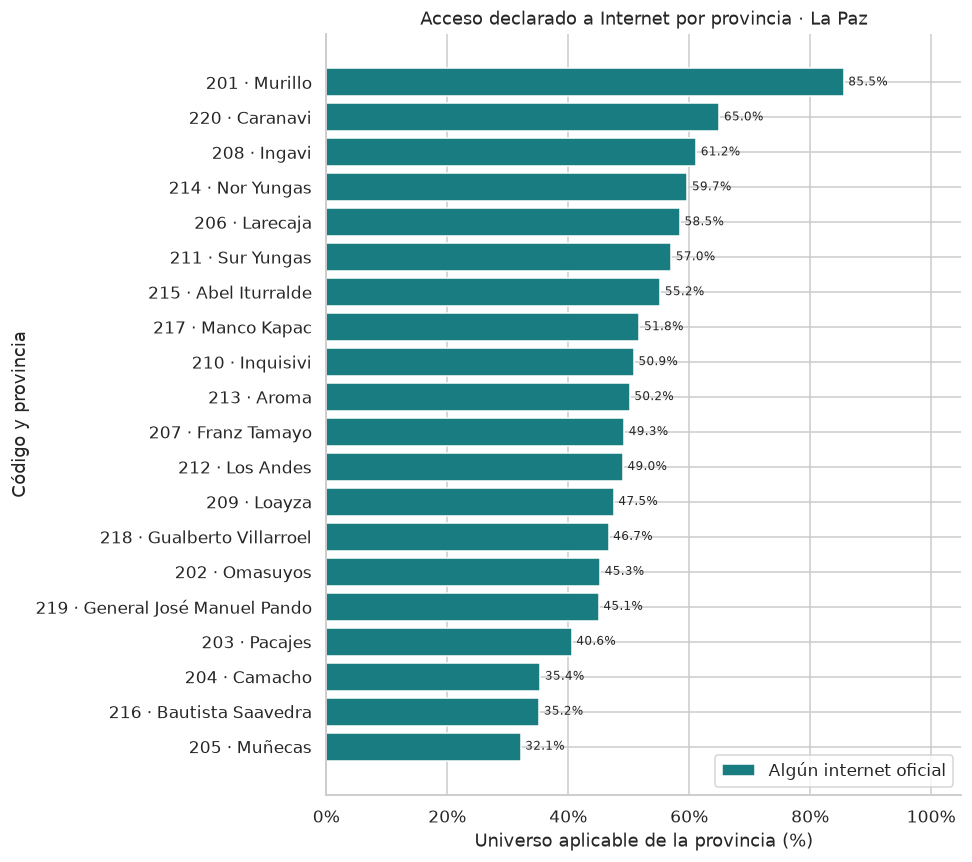

La provincia con mayor acceso declarado es **Murillo (85,55 %)** y la menor es **Muñecas (32,14 %)**. Las tasas provinciales se calculan sumando viviendas, no promediando porcentajes municipales.

In [16]:
provincias = resumen_grupos(["provincia_codigo", "provincia"]).sort_values("pct_algun", ascending=False)
display(provincias[COLUMNAS_RESUMEN])
fig, ax = plt.subplots(figsize=(9, 8))
p = provincias.reset_index().sort_values("pct_algun")
b = ax.barh(p.provincia_codigo + " · " + p.provincia, p.pct_algun, color="#197c80", label="Algún internet oficial")
ax.bar_label(b, fmt="%.1f%%", padding=3, fontsize=8)
ax.set(title="Acceso declarado a Internet por provincia · La Paz", xlabel="Universo aplicable de la provincia (%)", ylabel="Código y provincia", xlim=(0, 105))
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.legend(loc="lower right")
guardar_figura(fig, "17_provincias")
texto(f"La provincia con mayor acceso declarado es **{provincias.index[0][1]} "
      f"({decimal(provincias.iloc[0].pct_algun)} %)** y la menor es "
      f"**{provincias.index[-1][1]} ({decimal(provincias.iloc[-1].pct_algun)} %)**. "
      "Las tasas provinciales se calculan sumando viviendas, no promediando porcentajes municipales.")

### 18. Municipio
Se agrupa por **código municipal completo**, porque `imun` se repite entre provincias.
El ranking usa acceso declarado sobre el universo aplicable; la tabla completa
incluye respuestas determinadas y tasas alternativas. No se impone un mínimo
arbitrario: se procesa el censo completo y se muestra el denominador de cada municipio.
Los tamaños pequeños pueden hacer las tasas sensibles a pocos registros; el tamaño
mínimo observado se informa. Una tasa censal no elimina posibles errores de declaración.

,,universo,validos_fijo,validos_movil,validos_algun,pct_fijo,pct_movil,pct_algun,pct_sin_internet,pct_sin_especificar
municipio_codigo,municipio,,,,,,,,,
20101,Nuestra Señora de La Paz,250931,246906,246903,246907,70.21,78.06,89.84,8.56,1.60
20105,El Alto,297898,292189,292189,292198,50.91,70.72,84.12,13.97,1.91
20606,Tipuani,3243,3156,3156,3156,6.32,71.11,72.43,24.88,2.68
20607,Mapiri,6898,6600,6600,6601,3.25,70.70,71.60,24.09,4.31
20801,Viacha,41941,40640,40641,40642,26.01,62.02,69.36,27.54,3.10
...,...,...,...,...,...,...,...,...,...,...
20402,Mocomoco,8013,7576,7572,7577,0.77,33.53,33.88,60.68,5.44
20202,Villa Ancoraimes,6737,6448,6446,6448,1.16,33.20,33.61,62.10,4.29
20303,Calacoto,5108,4903,4903,4903,0.31,30.13,30.25,65.74,4.01


Top 10 de mayor conectividad


,,universo,validos_fijo,validos_movil,validos_algun,pct_fijo,pct_movil,pct_algun,pct_sin_internet,pct_sin_especificar
municipio_codigo,municipio,,,,,,,,,
20101,Nuestra Señora de La Paz,250931,246906,246903,246907,70.21,78.06,89.84,8.56,1.60
20105,El Alto,297898,292189,292189,292198,50.91,70.72,84.12,13.97,1.91
20606,Tipuani,3243,3156,3156,3156,6.32,71.11,72.43,24.88,2.68
20607,Mapiri,6898,6600,6600,6601,3.25,70.70,71.60,24.09,4.31
20801,Viacha,41941,40640,40641,40642,26.01,62.02,69.36,27.54,3.10
20104,Achocalla,16297,15641,15639,15641,19.99,63.58,68.86,27.12,4.03
21103,Yanacachi,2998,2903,2905,2905,3.80,67.88,68.71,28.19,3.10
21502,San Buenaventura,2849,2720,2720,2720,14.71,64.20,67.81,27.66,4.53
20103,Mecapaca,6849,6683,6683,6683,25.92,61.54,67.16,30.41,2.42


Bottom 10 de menor conectividad


,,universo,validos_fijo,validos_movil,validos_algun,pct_fijo,pct_movil,pct_algun,pct_sin_internet,pct_sin_especificar
municipio_codigo,municipio,,,,,,,,,
20502,Ayata,3494,3251,3251,3251,1.06,23.93,24.33,68.72,6.95
20404,Humanata,2527,2465,2464,2465,0.79,28.93,29.40,68.14,2.45
20303,Calacoto,5108,4903,4903,4903,0.31,30.13,30.25,65.74,4.01
20202,Villa Ancoraimes,6737,6448,6446,6448,1.16,33.20,33.61,62.10,4.29
20402,Mocomoco,8013,7576,7572,7577,0.77,33.53,33.88,60.68,5.44
21602,Curva,1656,1562,1562,1562,1.45,33.39,34.00,60.33,5.68
20501,Chuma,6388,6060,6060,6060,1.25,33.50,34.08,60.79,5.13
21204,Puerto Pérez,3188,3033,3033,3033,2.16,34.07,35.01,60.13,4.86
20308,Santiago de Callapa,3569,3314,3314,3314,0.59,34.72,35.02,57.83,7.14


Se identifican **87 municipios** y **20 provincias**, con un mínimo de **881 registros aplicables** y **858 respuestas determinadas combinadas** por municipio.

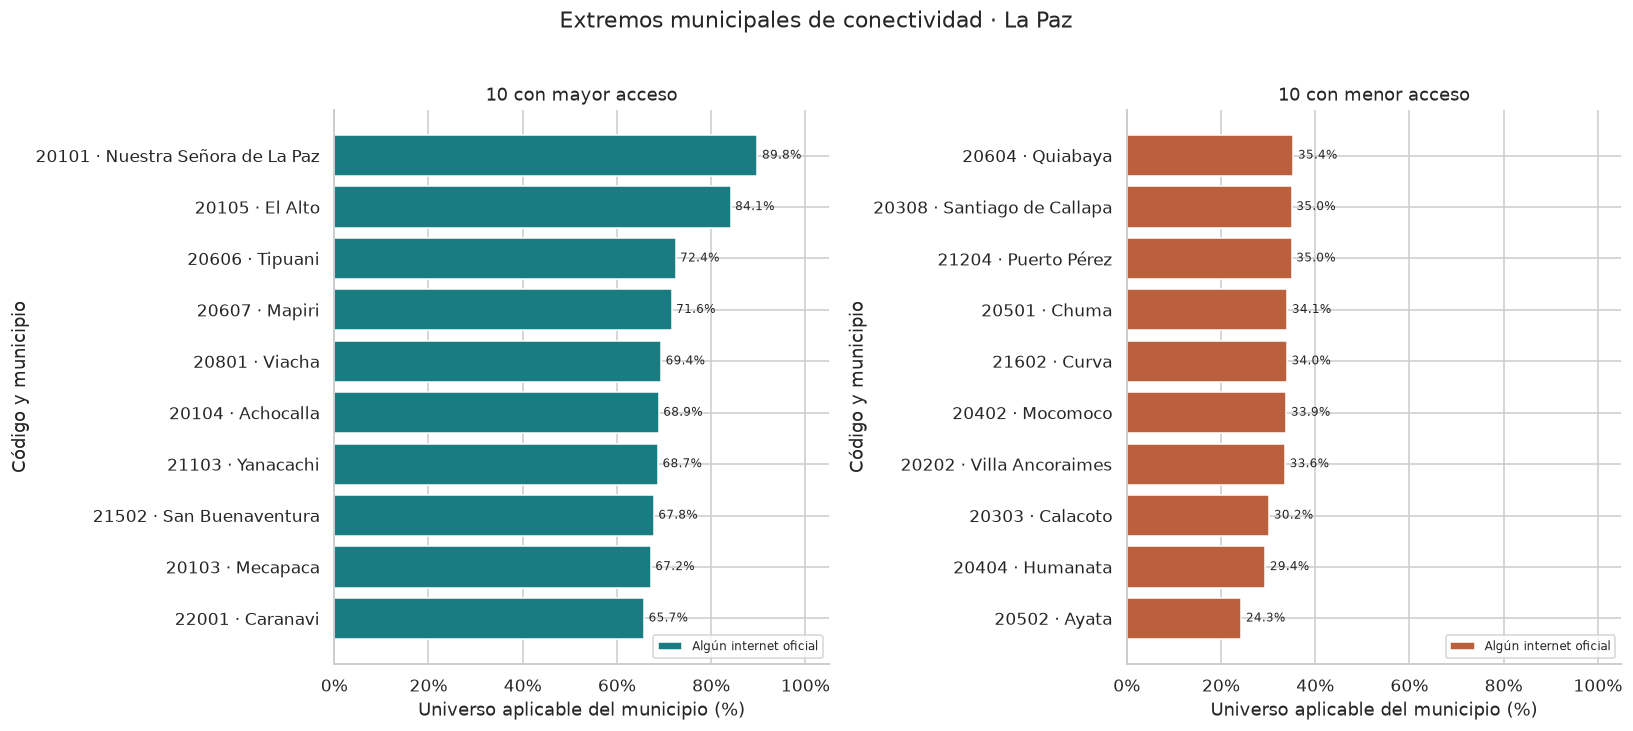

El mayor acceso corresponde a **Nuestra Señora de La Paz (89,84 %)** y el menor a **Ayata (24,33 %)**. Son proporciones sobre viviendas aplicables de cada territorio, no cantidades absolutas de conexiones.

In [17]:
municipios = resumen_grupos(["municipio_codigo", "municipio"]).sort_values("pct_algun", ascending=False)
display(municipios[COLUMNAS_RESUMEN])
top10 = municipios.head(10)
bottom10 = municipios.tail(10).sort_values("pct_algun")
print("Top 10 de mayor conectividad")
display(top10[COLUMNAS_RESUMEN])
print("Bottom 10 de menor conectividad")
display(bottom10[COLUMNAS_RESUMEN])
texto(f"Se identifican **{len(municipios)} municipios** y **{len(provincias)} provincias**, "
      f"con un mínimo de **{entero(municipios.universo.min())} registros aplicables** "
      f"y **{entero(municipios.validos_algun.min())} respuestas determinadas combinadas** por municipio.")
fig, ejes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, tabla, titulo, color in zip(ejes, [top10, bottom10], ["10 con mayor acceso", "10 con menor acceso"], ["#197c80", "#bb603d"]):
    t = tabla.reset_index().sort_values("pct_algun")
    b = ax.barh(t.municipio_codigo + " · " + t.municipio, t.pct_algun, color=color, label="Algún internet oficial")
    ax.bar_label(b, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set(title=titulo, xlabel="Universo aplicable del municipio (%)", ylabel="Código y municipio", xlim=(0, 105))
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("Extremos municipales de conectividad · La Paz", y=1.02)
guardar_figura(fig, "18_ranking_municipios")
texto(f"El mayor acceso corresponde a **{municipios.index[0][1]} "
      f"({decimal(municipios.iloc[0].pct_algun)} %)** y el menor a "
      f"**{municipios.index[-1][1]} ({decimal(municipios.iloc[-1].pct_algun)} %)**. "
      "Son proporciones sobre viviendas aplicables de cada territorio, no cantidades absolutas de conexiones.")

### 19. MISIÓN 3: outlier real
Se aplica la regla de Tukey (1,5 × IQR) a la distribución municipal de `% algún
internet`. Cada municipio pesa una vez: esta distribución describe territorios,
no la distribución de viviendas. Se identifica un territorio atípico, sin asumir
que sea un error y sin eliminarlo. Los límites se calculan sin recortarlos a 0–100.

,porcentaje / pp
Q1,40.91
Q3,56.28
IQR,15.38
Límite inferior,17.84
Límite superior,79.35


,,universo,validos_fijo,validos_movil,validos_algun,pct_fijo,pct_movil,pct_algun,pct_sin_internet,pct_sin_especificar
municipio_codigo,municipio,,,,,,,,,
20101,Nuestra Señora de La Paz,250931,246906,246903,246907,70.21,78.06,89.84,8.56,1.60
20105,El Alto,297898,292189,292189,292198,50.91,70.72,84.12,13.97,1.91


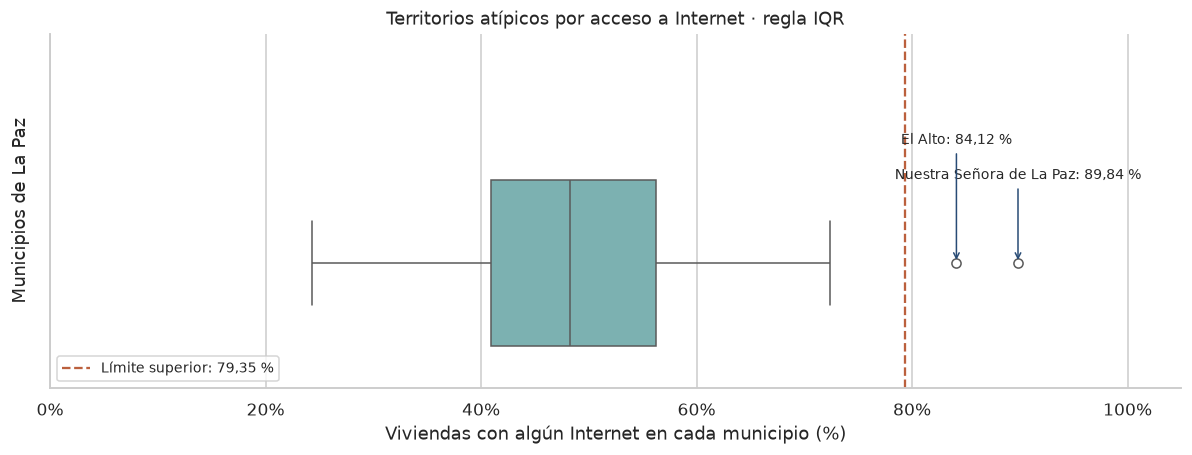

Hay **2 municipios atípicos**: **Nuestra Señora de La Paz (89,84 %)**; **El Alto (84,12 %)**. Superan el límite superior de **79,35 %**. Su acceso declarado es excepcional frente a la distribución municipal; no se consideran errores.

In [18]:
tasas = municipios.pct_algun.astype(float)
q1, q3 = tasas.quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
limites_iqr = pd.Series({"Q1": q1, "Q3": q3, "IQR": iqr,
                         "Límite inferior": limite_inferior, "Límite superior": limite_superior}, name="porcentaje / pp")
outliers = municipios[(tasas < limite_inferior) | (tasas > limite_superior)]
display(limites_iqr.to_frame())
display(outliers[COLUMNAS_RESUMEN])
fig, ax = plt.subplots(figsize=(11, 4.3))
sns.boxplot(x=tasas, ax=ax, color="#73baba", whis=1.5)
ax.axvline(limite_superior, ls="--", color="#bb603d", label=f"Límite superior: {decimal(limite_superior)} %")
for j, (idx, fila) in enumerate(outliers.iterrows()):
    ax.annotate(f"{idx[1]}: {decimal(fila.pct_algun)} %", xy=(fila.pct_algun, 0),
                xytext=(0, 55 + j * 23), textcoords="offset points", ha="center", fontsize=9,
                arrowprops={"arrowstyle": "->", "color": "#284b75"})
ax.set(title="Territorios atípicos por acceso a Internet · regla IQR", xlabel="Viviendas con algún Internet en cada municipio (%)", ylabel="Municipios de La Paz", xlim=(0, 105), ylim=(0.6, -1.1))
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.legend(loc="lower left", fontsize=9)
guardar_figura(fig, "19_outliers_iqr")
texto(f"Hay **{len(outliers)} municipios atípicos**: " + "; ".join(
    f"**{idx[1]} ({decimal(fila.pct_algun)} %)**" for idx, fila in outliers.iterrows()) +
    f". Superan el límite superior de **{decimal(limite_superior)} %**. "
    "Su acceso declarado es excepcional frente a la distribución municipal; no se consideran errores.")

### 20. MISIÓN 3: distribución interesante

,% algún internet por municipio
count,87.00
mean,49.39
std,12.00
min,24.33
25%,40.91
50%,48.23
75%,56.28
max,89.84


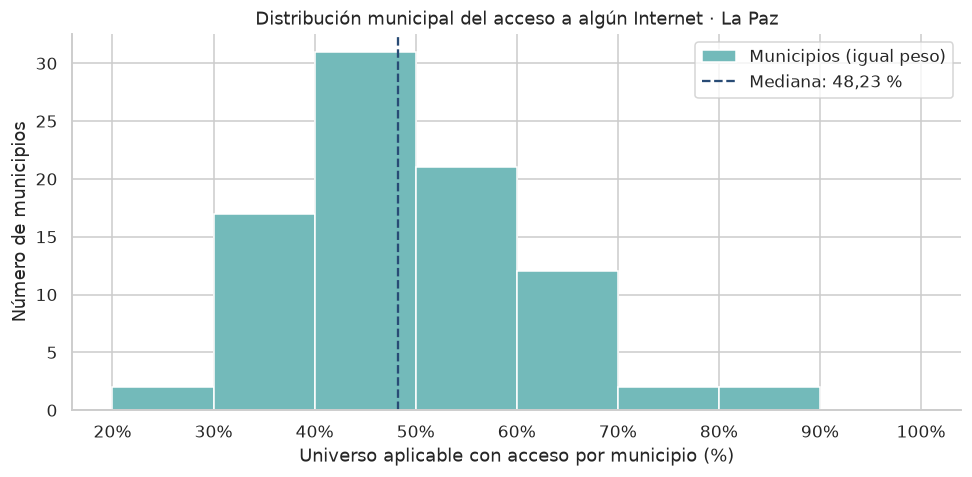

La mitad central de los municipios se encuentra entre **40,91 % y 56,28 %**. La mediana es **48,23 %**, la desviación estándar **12,00 pp** y los extremos **24,33 %–89,84 %**. La asimetría es **0,76**, compatible con una cola hacia tasas altas. La media municipal sin ponderar (49,39 %) difiere de la tasa departamental (69,95 %), que pondera por viviendas. Los municipios grandes concentran una parte importante de los accesos.

In [19]:
distribucion = tasas.describe().to_frame("% algún internet por municipio")
display(distribucion)
asimetria = float(tasas.skew())
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(tasas, bins=np.arange(20, 101, 10), color="#73baba", edgecolor="white", label="Municipios (igual peso)")
ax.axvline(tasas.median(), color="#284b75", ls="--", label=f"Mediana: {decimal(tasas.median())} %")
ax.set(title="Distribución municipal del acceso a algún Internet · La Paz", xlabel="Universo aplicable con acceso por municipio (%)", ylabel="Número de municipios")
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.legend()
guardar_figura(fig, "20_distribucion")
texto(f"La mitad central de los municipios se encuentra entre **{decimal(q1)} % y {decimal(q3)} %**. "
      f"La mediana es **{decimal(tasas.median())} %**, la desviación estándar **{decimal(tasas.std())} pp** "
      f"y los extremos **{decimal(tasas.min())} %–{decimal(tasas.max())} %**. "
      f"La asimetría es **{decimal(asimetria)}**, compatible con una cola hacia tasas altas. "
      f"La media municipal sin ponderar ({decimal(tasas.mean())} %) difiere de la tasa departamental "
      f"({decimal(comparacion.loc['Algún internet', '% Sí'])} %), que pondera por viviendas. "
      "Los municipios grandes concentran una parte importante de los accesos.")

### 21. MISIÓN 3: relación relevante
**Área urbana/rural ↔ acceso a Internet.** Ambas son categóricas: se usan tablas
cruzadas y proporciones, no Pearson sobre códigos 1/2/9. Para resumir intensidad se
calcula V de Cramér sobre la tabla 2×2 de respuestas determinadas. Se presenta el
chi-cuadrado descriptivo usado para calcular V, sin prueba ni p-valor de muestreo:
se analiza un censo completo y la enorme cantidad de registros haría poco informativa
la significación. La diferencia en puntos porcentuales es el resultado principal.
No se infiere causalidad; ingreso, infraestructura y composición de las viviendas
podrían explicar parte de la asociación y no se controlan en este EDA.

In [20]:
cruce_area = pd.crosstab(df_analisis.area_label, df_analisis.internet_combinado_label).reindex(
    index=["Urbana", "Rural"], columns=["Sí", "No", "Sin especificar"], fill_value=0)
display(cruce_area)
display(cruce_area.div(cruce_area.sum(axis=1), axis=0) * 100)
observados = cruce_area[["Sí", "No"]].to_numpy(dtype=float)
esperados = np.outer(observados.sum(axis=1), observados.sum(axis=0)) / observados.sum()
assert (esperados > 0).all()
chi2_descriptivo = float(((observados - esperados) ** 2 / esperados).sum())
v_cramer = float(np.sqrt(chi2_descriptivo / (observados.sum() * min(np.array(observados.shape) - 1))))
display(pd.Series({"Respuestas determinadas en tabla 2×2": observados.sum(),
    "Frecuencia esperada mínima": esperados.min(), "Chi-cuadrado descriptivo": chi2_descriptivo,
    "V de Cramér (0 a 1)": v_cramer, "Brecha urbana-rural (pp, universo aplicable)": brecha_area_pp}).to_frame("valor"))
texto(f"La brecha urbana-rural es **{decimal(brecha_area_pp)} pp** sobre el universo aplicable. "
      f"V de Cramér = **{decimal(v_cramer)}** entre respuestas determinadas, "
      "lo que cuantifica una asociación observable. V no indica dirección ni demuestra causalidad.")

internet_combinado_label,Sí,No,Sin especificar
area_label,,,
Urbana,558607,91874,13966
Rural,189794,199066,16531


internet_combinado_label,Sí,No,Sin especificar
area_label,,,
Urbana,84.07,13.83,2.10
Rural,46.82,49.10,4.08


,valor
Respuestas determinadas en tabla 2×2,"1,039,341.00"
Frecuencia esperada mínima,"108,852.56"
Chi-cuadrado descriptivo,"165,901.76"
V de Cramér (0 a 1),0.40
"Brecha urbana-rural (pp, universo aplicable)",37.25


La brecha urbana-rural es **37,25 pp** sobre el universo aplicable. V de Cramér = **0,40** entre respuestas determinadas, lo que cuantifica una asociación observable. V no indica dirección ni demuestra causalidad.

### 22. MISIÓN 4: hipótesis

In [21]:
hipotesis = (f"Creemos que el área de residencia influye en el acceso a Internet fijo o móvil "
    f"porque observamos {decimal(areas.loc['Urbana', 'pct_algun'])} % de acceso declarado en viviendas urbanas "
    f"frente a {decimal(areas.loc['Rural', 'pct_algun'])} % en rurales, "
    f"una diferencia de {decimal(brecha_area_pp)} puntos porcentuales.")
texto(f'**“{hipotesis}”**')
texto("La palabra influye expresa una hipótesis por investigar. Los datos observacionales "
      "de este EDA demuestran asociación, no una relación causal identificada.")

**“Creemos que el área de residencia influye en el acceso a Internet fijo o móvil porque observamos 84,07 % de acceso declarado en viviendas urbanas frente a 46,82 % en rurales, una diferencia de 37,25 puntos porcentuales.”**

La palabra influye expresa una hipótesis por investigar. Los datos observacionales de este EDA demuestran asociación, no una relación causal identificada.

### 23. Hallazgo principal para exposición (aproximadamente 30 segundos)

In [22]:
hallazgo = (f"En el Censo 2024 analizamos {entero(universo_n)} viviendas particulares con personas presentes "
    f"en La Paz. El {decimal(comparacion.loc['Móvil', '% Sí'])} % declara Internet móvil y el "
    f"{decimal(comparacion.loc['Fijo', '% Sí'])} % Internet fijo. "
    f"La diferencia territorial también es clara: algún Internet alcanza al "
    f"{decimal(areas.loc['Urbana', 'pct_algun'])} % urbano frente al {decimal(areas.loc['Rural', 'pct_algun'])} % rural. "
    "Esto sugiere una desigualdad de acceso asociada al área de residencia; no prueba causalidad. "
    "Los porcentajes incluyen las respuestas sin especificar en el denominador.")
texto(hallazgo)

En el Censo 2024 analizamos 1.069.838 viviendas particulares con personas presentes en La Paz. El 62,55 % declara Internet móvil y el 33,92 % Internet fijo. La diferencia territorial también es clara: algún Internet alcanza al 84,07 % urbano frente al 46,82 % rural. Esto sugiere una desigualdad de acceso asociada al área de residencia; no prueba causalidad. Los porcentajes incluyen las respuestas sin especificar en el denominador.

### 24. Conclusiones

In [23]:
conclusiones = [
    f"De {entero(len(df_lapaz))} registros de La Paz, {entero(universo_n)} pertenecen al universo TIC; "
    f"{entero((~aplicable).sum())} tienen saltos fuera de ese universo y no se clasifican como desconectados.",
    f"Internet móvil ({decimal(comparacion.loc['Móvil', '% Sí'])} %) supera al fijo "
    f"({decimal(comparacion.loc['Fijo', '% Sí'])} %) en {decimal(dif_pp)} pp y {entero(dif_absoluta)} viviendas.",
    f"El indicador combinado oficial registra {entero(comparacion.loc['Algún internet', 'Sí'])} viviendas con acceso "
    f"({decimal(comparacion.loc['Algún internet', '% Sí'])} %); "
    f"{entero(comparacion.loc['Algún internet', 'Sin especificar'])} quedan sin especificar "
    f"({decimal(comparacion.loc['Algún internet', '% Sin especificar'])} %).",
    f"El acceso urbano ({decimal(areas.loc['Urbana', 'pct_algun'])} %) excede al rural "
    f"({decimal(areas.loc['Rural', 'pct_algun'])} %) en {decimal(brecha_area_pp)} pp; "
    f"la asociación tiene V de Cramér de {decimal(v_cramer)} entre respuestas determinadas.",
    f"Entre {len(municipios)} municipios, la mediana de acceso es {decimal(tasas.median())} %. "
    f"{len(outliers)} superan el límite IQR de {decimal(limite_superior)} %: "
    + "; ".join(f"{idx[1]} ({decimal(fila.pct_algun)} %)" for idx, fila in outliers.iterrows()) + ".",
]
texto("\n\n".join(f"{i}. {s}" for i, s in enumerate(conclusiones, 1)))

1. De 1.334.496 registros de La Paz, 1.069.838 pertenecen al universo TIC; 264.658 tienen saltos fuera de ese universo y no se clasifican como desconectados.

2. Internet móvil (62,55 %) supera al fijo (33,92 %) en 28,64 pp y 306.355 viviendas.

3. El indicador combinado oficial registra 748.401 viviendas con acceso (69,95 %); 30.497 quedan sin especificar (2,85 %).

4. El acceso urbano (84,07 %) excede al rural (46,82 %) en 37,25 pp; la asociación tiene V de Cramér de 0,40 entre respuestas determinadas.

5. Entre 87 municipios, la mediana de acceso es 48,23 %. 2 superan el límite IQR de 79,35 %: Nuestra Señora de La Paz (89,84 %); El Alto (84,12 %).

### 25. Mini evaluación

1. **¿Qué información brinda un boxplot?** Muestra mediana, cuartiles, rango
   intercuartílico y dispersión. Los bigotes alcanzan los valores observados dentro
   de 1,5 IQR; los puntos exteriores son candidatos atípicos, no errores automáticos.
2. **¿Qué significa una correlación cercana a 1?** En Pearson, una asociación lineal
   positiva intensa entre variables cuantitativas; en Spearman, una asociación
   monótona positiva intensa entre rangos. No demuestra causalidad. No corresponde
   aplicar Pearson a códigos nominales como Sí=1, No=2 y Sin especificar=9.
3. **¿Qué hacer cuando existen valores faltantes?** Cuantificarlos e investigar su
   origen y universo, separando vacíos por salto, no respuesta y categorías
   explícitas. Documentar denominadores y, según el objetivo, excluir justificadamente,
   imputar con un método defendible o conservarlos. Aquí no se imputan respuestas TIC.
4. **¿Por qué el EDA se realiza antes del modelado?** Permite entender unidad de
   análisis, cobertura, tipos, calidad y relaciones; evita entrenar sobre categorías
   mal interpretadas, sesgos de selección o denominadores incorrectos y orienta
   hipótesis que posteriormente se deben contrastar.

**Limitaciones:** `i00` y componentes geográficos no tienen definición directa en
el diccionario; los nombres se obtienen por correspondencia de catálogos validada.
No hay ponderación por personas ni medición de calidad de servicio. No se conoce el
algoritmo de la combinada oficial y se informa su divergencia frente a una regla
conservadora. «Sin especificar» sigue siendo una fuente de incertidumbre; las tasas
principales miden acceso declarado y no imputan el acceso de quienes no responden.
Las conclusiones describen 2024 y no establecen causalidad ni cambios temporales.

### Validación y exportación reproducible
Se exportan solo tablas agregadas, gráficos y un resumen; la copia filtrada de los
microdatos se guarda localmente en `outputs/datos/`, excluida de Git.
Las huellas SHA-256 de las tres fuentes utilizadas deben coincidir al terminar.
Las comprobaciones aseguran totales, particiones, catálogos, denominadores y gráficos.

In [24]:
assert len(df_lapaz) == universo_n + int((~aplicable).sum())
assert int(conteo_departamentos.sum()) == registros_nacionales
assert int(areas.universo.sum()) == int(provincias.universo.sum()) == int(municipios.universo.sum()) == universo_n
assert np.allclose(municipios[["pct_algun", "pct_sin_internet", "pct_sin_especificar"]].sum(axis=1), 100)
assert ((municipios.pct_algun >= municipios.pct_fijo) & (municipios.pct_algun >= municipios.pct_movil)).all()
assert int(fuera_catalogo.fuera_catalogo.sum()) == 0
assert int(auditoria_geo.cantidad.sum()) == 0
assert int(auditoria_universo.vacios_dentro_universo.sum()) == 0
assert int(auditoria_universo.respuesta_fuera_universo.sum()) == 0
assert duplicados["i00_repeticiones_adicionales"] == 0
assert int(comparacion.loc["Fijo", "Sí"] + comparacion.loc["Móvil", "Sí"] - ambos) == int(comparacion.loc["Algún internet", "Sí"])
for p in [CSV_VIVIENDA, DICCIONARIO, CUESTIONARIO]:
    assert huella(p) == originales[p.name]["sha256"], f"Se modificó la fuente {p.name}"

tablas_exportar = {"inventario": inventario, "diccionario_utilizado": tabla_diccionario,
    "estructura": resumen_estructura, "faltantes": faltantes, "universo": auditoria_universo,
    "fuera_catalogo": fuera_catalogo, "auditoria_geografica": auditoria_geo,
    "correspondencia_geografica": geografia, "comparacion": comparacion,
    "internet_fijo": tabla_fijo, "internet_movil": tabla_movil, "internet_combinado": tabla_combinada,
    "sensibilidad": sensibilidad, "sensibilidad_tasas": sensibilidad_tasas,
    "areas": areas, "provincias": provincias, "municipios": municipios,
    "top10": top10, "bottom10": bottom10, "outliers": outliers,
    "limites_iqr": limites_iqr.to_frame(), "distribucion": distribucion, "relacion_area": cruce_area}
for nombre, tabla in tablas_exportar.items():
    tabla.to_csv(TABLAS / f"{nombre}.csv", index=True, encoding="utf-8-sig")

resumen = {"fuentes": originales, "registros_nacionales": registros_nacionales,
    "columnas_originales": len(formato["cabecera"]), "variables_seleccionadas": VARIABLES,
    "codigo_lapaz": CODIGO_LAPAZ, "registros_lapaz": len(df_lapaz), "universo_tic": universo_n,
    "fuera_universo": int((~aplicable).sum()),
    "comparacion": comparacion.reset_index().to_dict(orient="records"),
    "duplicados": duplicados, "inconsistencias": inconsistencias,
    "diferencia_movil_fijo_registros": dif_absoluta, "diferencia_movil_fijo_pp": dif_pp,
    "diferencia_relativa_pct": float(dif_relativa), "brecha_urbano_rural_pp": brecha_area_pp,
    "areas": areas.reset_index().to_dict(orient="records"), "v_cramer": v_cramer,
    "outliers": outliers.reset_index().to_dict(orient="records"), "iqr": limites_iqr.to_dict(),
    "mediana_municipal": float(tasas.median()), "asimetria_municipal": asimetria,
    "hipotesis": hipotesis, "hallazgo_30_segundos": hallazgo, "conclusiones": conclusiones}
(SALIDA / "resumen_eda.json").write_text(json.dumps(resumen, ensure_ascii=False, indent=2), encoding="utf-8")
figuras_esperadas = ["12_internet_fijo", "13_internet_movil", "14_algun_internet", "15_fijo_vs_movil",
    "16_urbano_rural", "17_provincias", "18_ranking_municipios", "19_outliers_iqr", "20_distribucion"]
assert all((GRAFICOS / f"{f}.png").is_file() for f in figuras_esperadas)
print("VALIDACIÓN CORRECTA: totales, universos, catálogos y 9 gráficos verificados; fuentes sin modificaciones.")
print("Tablas agregadas:", TABLAS.relative_to(RAIZ))
print("Resumen:", (SALIDA / "resumen_eda.json").relative_to(RAIZ))

VALIDACIÓN CORRECTA: totales, universos, catálogos y 9 gráficos verificados; fuentes sin modificaciones.
Tablas agregadas: outputs/tablas
Resumen: outputs/resumen_eda.json
